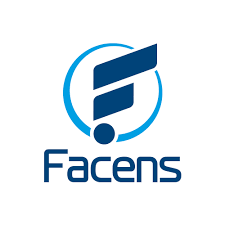
</p>

<br/>
  
<font size="3"><center>Prof. Julio Cesar Mastrodomenico</center></font>




# Aprendizado de Máquinas
### 2023PGS2M2
----

## <center> Métodos de Ensemble </center>

Implementação e utilização de Métodos de Ensemble

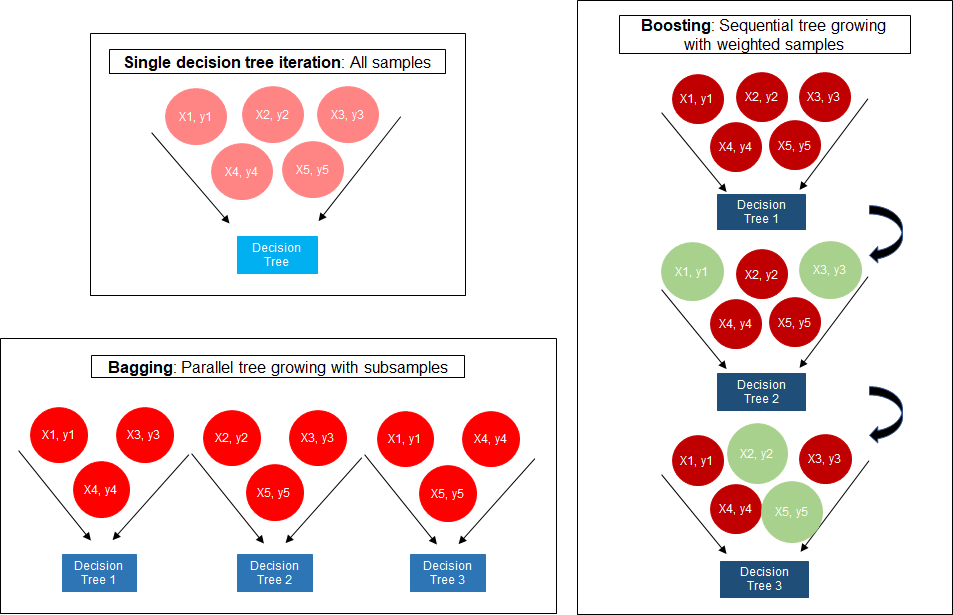

Banco de dados:
- Social Ads Network
- Iris
- Data3
- Titanic
- Digits
- Breast Cancer
- Data_cancer

### Exercícios

## 1) Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, \
                            f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import datasets
import random
from sklearn.pipeline import Pipeline
from glob import glob
from tqdm.notebook import tqdm

# Nossas ferramentas
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score

# Nossos Algoritmos
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC

# Ensemble
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier

## 2) Primeiro exercício e visualização da superfície de decisão
-----------------------

### Random Forest Classifier

In [2]:
# Exercicio com o dataset 2D, Social Network Ads
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [5]:
classifier = RandomForestClassifier(n_estimators=10)
classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10)

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [7]:
y_pred = classifier.predict(X_test)

In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[66  2]
 [ 4 28]]


0.94

### Visualização

<ipython-input-9-4597f0c96ba6>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


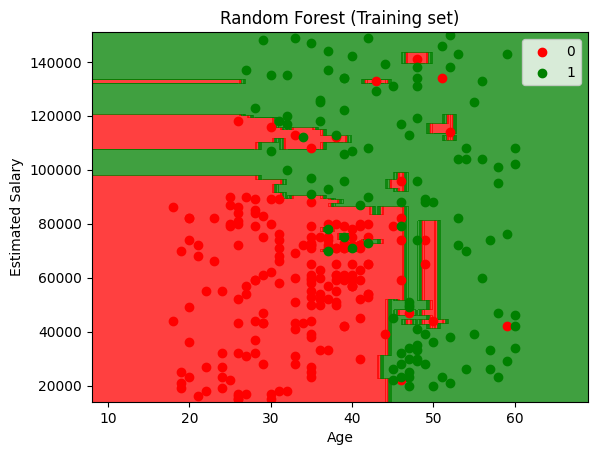

In [9]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

<ipython-input-10-448715917f9a>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


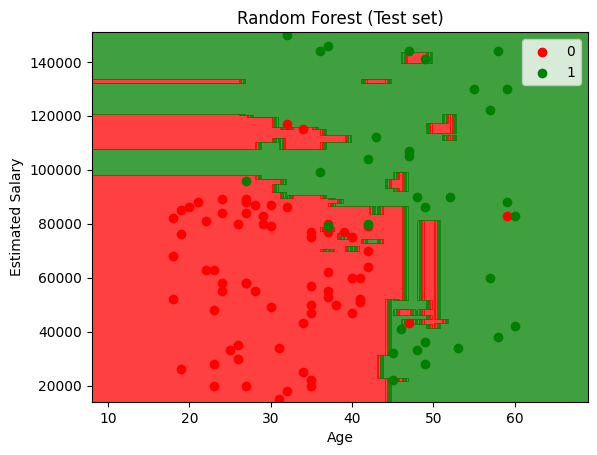

In [10]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Adaboost

In [11]:
classifier = AdaBoostClassifier()
classifier.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier()

In [12]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [13]:
y_pred = classifier.predict(X_test)

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[64  4]
 [ 5 27]]


0.91

### Visualização:

<ipython-input-15-4ce89254c98e>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


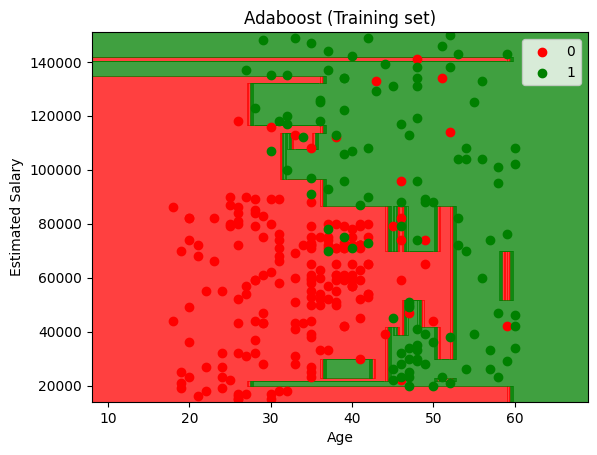

In [15]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Adaboost (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

<ipython-input-16-5f36ac9e9e67>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


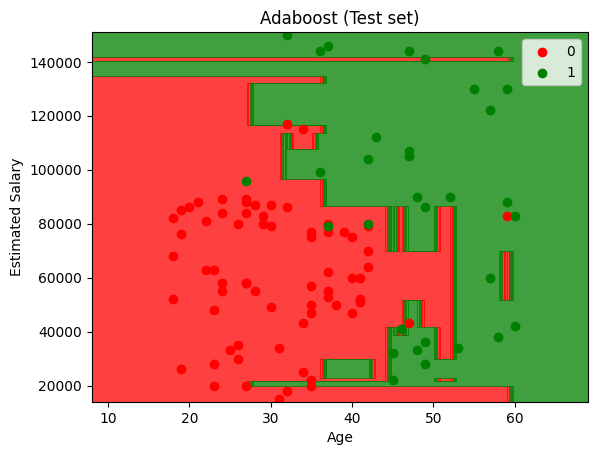

In [16]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Adaboost (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Bagging Classifier

In [17]:
classifier = BaggingClassifier()
classifier.fit(X_train, y_train)

BaggingClassifier()

In [18]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [19]:
y_pred = classifier.predict(X_test)

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[65  3]
 [ 5 27]]


0.92

### Visualização

<ipython-input-21-71a233086cbe>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


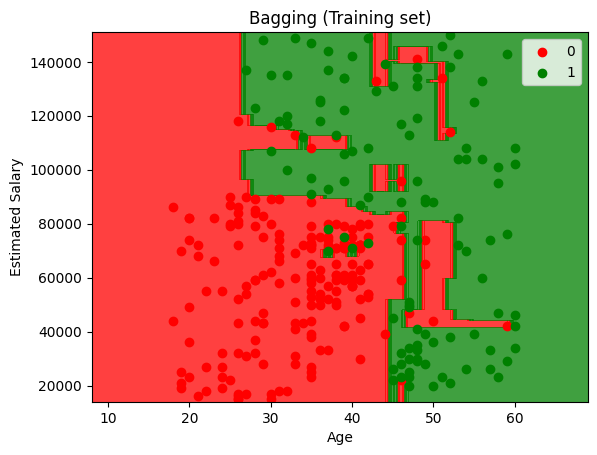

In [21]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Bagging (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

<ipython-input-22-416661903009>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


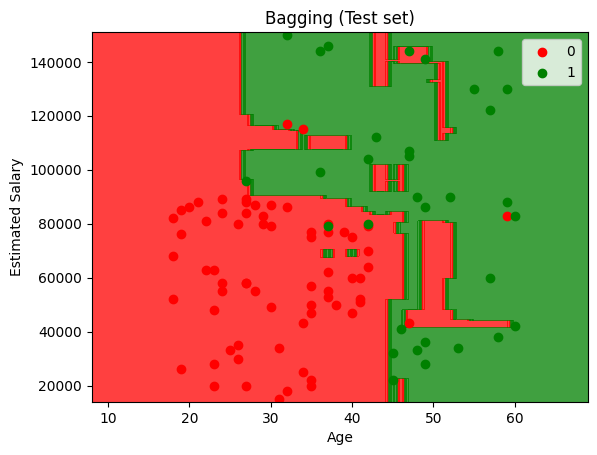

In [22]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Bagging (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## 3) Iris Dataset

In [23]:
# Importa o dataset do Iris direto do sklearn
loadiris = datasets.load_iris(as_frame=True)
df_iris = pd.concat((pd.DataFrame(loadiris.data),pd.DataFrame(loadiris.target)), axis=1)

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [24]:
# Visualizando nosso Dataset
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [25]:
df_iris['target'] = df_iris['target'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

In [26]:
df_iris['target'].value_counts()

,count
target,
1,100
0,50


In [27]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_iris.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
Y = df_iris.iloc[:, -1].values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

X: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Y: [0 0 0 0 0]


### Aplicando o PCA

In [28]:
# Dividindo em Train Test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [29]:
# Normalização dos dados por padronização
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [30]:
# Aplicar PCA no X_train e X_test ( 2 componentes )
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [31]:
# Classificador GradientBoosting com 10 estimators
classifier = GradientBoostingClassifier(n_estimators=10)
classifier.fit(X_train_pca, y_train)

GradientBoostingClassifier(n_estimators=10)

In [32]:
# Verificando a metrica
y_pred = classifier.predict(X_test_pca)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



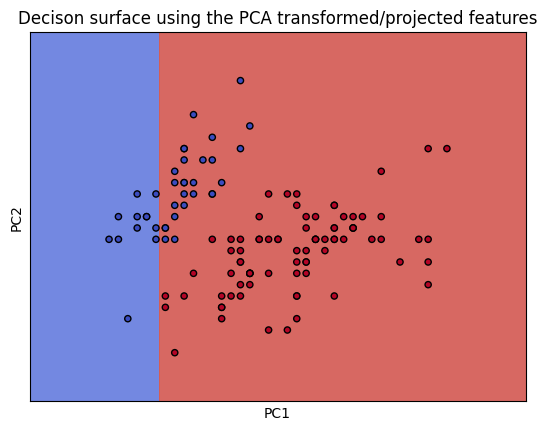

In [33]:
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

y = y_train
fig, ax = plt.subplots()

# Set-up grid for plotting.
X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, classifier, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('PC2')
ax.set_xlabel('PC1')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Decison surface using the PCA transformed/projected features')
plt.show()

## Exercício com o Dataset data3

In [34]:
# Importando o dataset
df_3 = pd.read_csv('/content/data3.csv', names=['FT1', 'FT2', 'Target'])

In [35]:
df_3

,FT1,FT2,Target
0,-0.158986,0.423977,1
1,-0.347926,0.470760,1
2,-0.504608,0.353801,1
3,-0.596774,0.114035,1
4,-0.518433,-0.172515,1
...,...,...,...
206,-0.399885,-0.621930,1
207,-0.124078,-0.126608,1
208,-0.316935,-0.228947,1
209,-0.294124,-0.134795,0


In [36]:
df_3.Target.value_counts()

,count
Target,
1,106
0,105


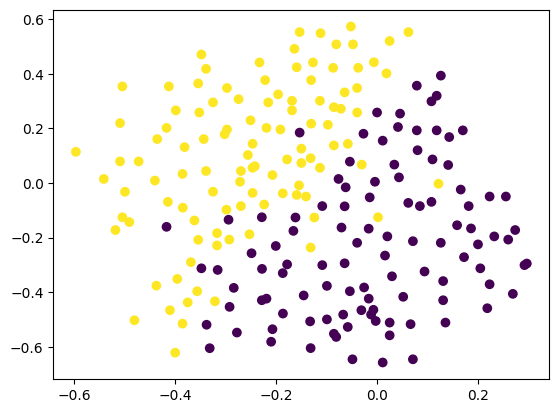

In [37]:
plt.scatter(df_3.iloc[:,0], df_3.iloc[:,1], c=df_3.iloc[:,2])

In [38]:
# Criando Classificador com ensemble a escolha

#1 metodo de bagging
bagging_class = BaggingClassifier()
bagging_class.fit(df_3.iloc[:,:2], df_3.iloc[:,2])





BaggingClassifier()

In [39]:
#2 metodo de boosting

boost_class = GradientBoostingClassifier()
boost_class.fit(df_3.iloc[:,:2], df_3.iloc[:,2])

GradientBoostingClassifier()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


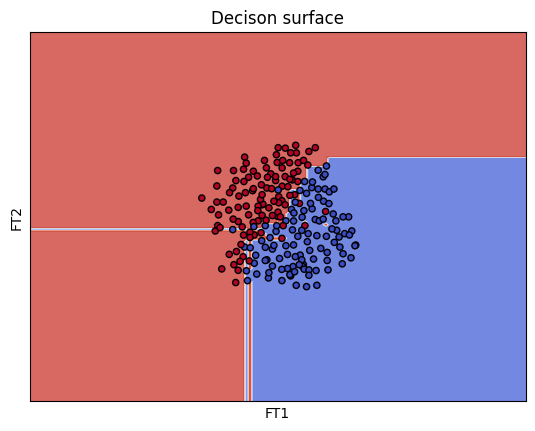

In [40]:
y = df_3.iloc[:,-1]
fig, ax = plt.subplots()

# Set-up grid for plotting.
X0, X1 = df_3.iloc[:,0], df_3.iloc[:,1]
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, boost_class, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('FT2')
ax.set_xlabel('FT1')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Decison surface')
plt.show()

In [41]:
df_3_val = pd.read_csv('/content/data3_val.csv', names=['FT1', 'FT2', 'Target'])

In [42]:
df_3_val

,FT1,FT2,Target
0,-0.353062,-0.673902,0
1,-0.227126,0.447320,1
2,0.092898,-0.753524,0
3,0.148243,-0.718473,0
4,-0.001512,0.162928,0
...,...,...,...
195,0.005203,-0.544449,1
196,0.176352,-0.572454,0
197,0.127651,-0.340938,0
198,0.248682,-0.497502,0


In [43]:
# Verificando a metrica

#bagging
y_pred = bagging_class.predict(df_3_val.iloc[:,:2])
print('Bagging Classifier')
print(classification_report(df_3_val.iloc[:,-1], y_pred))


Bagging Classifier
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       113
           1       0.92      0.92      0.92        87

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



In [44]:
#boosting
y_pred = boost_class.predict(df_3_val.iloc[:,:2])
print('Boosting Classifier')
print(classification_report(df_3_val.iloc[:,-1], y_pred))

Boosting Classifier
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       113
           1       0.92      0.92      0.92        87

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



## Exercício dataset Titanic

In [45]:
# Importando o csv para um pandas dataframe
df = pd.read_csv("/content/titanic.csv")
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [46]:
# Pandas get Dummies
dummies = pd.get_dummies(df['Sex'])

In [47]:
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [48]:
# Novo dataframe com os dummies
df_novo = pd.concat([df, dummies], axis='columns')

In [49]:
df_novo

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,female,male
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,False,True
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1,True,False
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True,False
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1,True,False
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",2,male,27.0,0,0,211536,13.0000,NaN,S,0,False,True
887,888,"Graham, Miss. Margaret Edith",1,female,19.0,0,0,112053,30.0000,B42,S,1,True,False
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,True,False
889,890,"Behr, Mr. Karl Howell",1,male,26.0,0,0,111369,30.0000,C148,C,1,False,True


In [50]:
# Remoção de colunas não relevantes
df_novo.drop(['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin'], axis='columns', inplace=True)

In [51]:
df_novo

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female,male
0,3,22.0,1,0,7.2500,S,0,False,True
1,1,38.0,1,0,71.2833,C,1,True,False
2,3,26.0,0,0,7.9250,S,1,True,False
3,1,35.0,1,0,53.1000,S,1,True,False
4,3,35.0,0,0,8.0500,S,0,False,True
...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,S,0,False,True
887,1,19.0,0,0,30.0000,S,1,True,False
888,3,NaN,1,2,23.4500,S,0,True,False
889,1,26.0,0,0,30.0000,C,1,False,True


In [52]:
# Visulizando os dados, realizando possíveis transformações
df_novo['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [53]:
df_novo['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [54]:
df_novo['Embarked'] = df_novo['Embarked'].fillna('S')

In [55]:
df_novo

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female,male
0,3,22.0,1,0,7.2500,S,0,False,True
1,1,38.0,1,0,71.2833,C,1,True,False
2,3,26.0,0,0,7.9250,S,1,True,False
3,1,35.0,1,0,53.1000,S,1,True,False
4,3,35.0,0,0,8.0500,S,0,False,True
...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,S,0,False,True
887,1,19.0,0,0,30.0000,S,1,True,False
888,3,NaN,1,2,23.4500,S,0,True,False
889,1,26.0,0,0,30.0000,C,1,False,True


In [56]:
# Instanciando o labelEncoder
le = LabelEncoder()

df_novo['Embarked'] = le.fit_transform(df_novo['Embarked'])

In [57]:
df_novo

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female,male
0,3,22.0,1,0,7.2500,2,0,False,True
1,1,38.0,1,0,71.2833,0,1,True,False
2,3,26.0,0,0,7.9250,2,1,True,False
3,1,35.0,1,0,53.1000,2,1,True,False
4,3,35.0,0,0,8.0500,2,0,False,True
...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,2,0,False,True
887,1,19.0,0,0,30.0000,2,1,True,False
888,3,NaN,1,2,23.4500,2,0,True,False
889,1,26.0,0,0,30.0000,0,1,False,True


In [58]:
df_novo['Age'] = df_novo['Age'].fillna(df_novo.Age.mean())

In [59]:
df_novo

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,female,male
0,3,22.000000,1,0,7.2500,2,0,False,True
1,1,38.000000,1,0,71.2833,0,1,True,False
2,3,26.000000,0,0,7.9250,2,1,True,False
3,1,35.000000,1,0,53.1000,2,1,True,False
4,3,35.000000,0,0,8.0500,2,0,False,True
...,...,...,...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,2,0,False,True
887,1,19.000000,0,0,30.0000,2,1,True,False
888,3,29.699118,1,2,23.4500,2,0,True,False
889,1,26.000000,0,0,30.0000,0,1,False,True


In [60]:
# Divisão em train test val
X_train, X_test, y_train, y_test = train_test_split(df_novo.drop(columns=['Survived']), df_novo.Survived.values, test_size=0.15, random_state = 0)

In [61]:
len(X_train)

757

In [62]:
len(X_test)

134

In [63]:
# Normalização dos dados por padronização
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [64]:
# Aplicando PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [65]:
# Escolhendo um método
classifier = GradientBoostingClassifier()
classifier.fit(X_train_pca, y_train)


GradientBoostingClassifier()

In [66]:
# Verificando a metrica
y_pred = classifier.predict(X_test_pca)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82        79
           1       0.77      0.67      0.72        55

    accuracy                           0.78       134
   macro avg       0.78      0.77      0.77       134
weighted avg       0.78      0.78      0.78       134



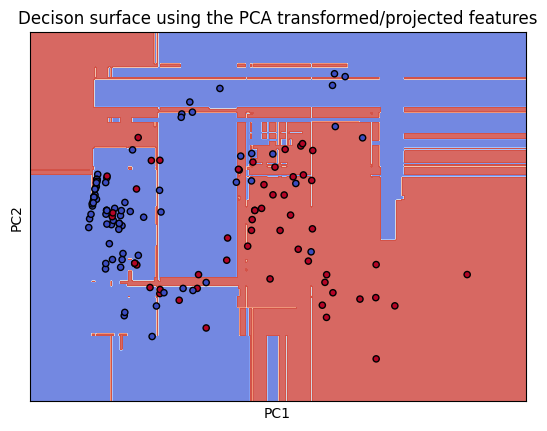

In [68]:
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

y = y_test
fig, ax = plt.subplots()

# Set-up grid for plotting.
X0, X1 = X_test_pca[:, 0], X_test_pca[:, 1]
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, classifier, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('PC2')
ax.set_xlabel('PC1')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Decison surface using the PCA transformed/projected features')
plt.show()

## Exercício dataset Wine ( direto do sklearn )

$ from sklearn import datasets

$ wine = datasets.load_wine()

In [69]:
# Carregando o dataset
wine = datasets.load_wine(as_frame=True)

In [70]:
wine.data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [71]:
wine.target.value_counts()

,count
target,
1,71
0,59
2,48


In [72]:
# Aplicar PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(wine.data)


In [73]:
# Divisão Train test
X_train, X_test, y_train, y_test = train_test_split(X_train_pca, wine.target.values, test_size=0.15, random_state = 0)


In [74]:
# Normalização dos dados
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [75]:
# Aplicando PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [76]:
# Validação com Voting
voting = VotingClassifier(estimators=[('bag', BaggingClassifier()),
 ('ada', AdaBoostClassifier()),('gr',GradientBoostingClassifier()),
  ('rf', RandomForestClassifier())], voting='hard')
voting.fit(X_train_pca, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


VotingClassifier(estimators=[('bag', BaggingClassifier()),
                             ('ada', AdaBoostClassifier()),
                             ('gr', GradientBoostingClassifier()),
                             ('rf', RandomForestClassifier())])

In [77]:
# Verificando a metrica
y_pred_voting = voting.predict(X_test_pca)
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.71      0.77      0.74        13
           2       0.20      0.20      0.20         5

    accuracy                           0.70        27
   macro avg       0.64      0.62      0.63        27
weighted avg       0.71      0.70      0.71        27



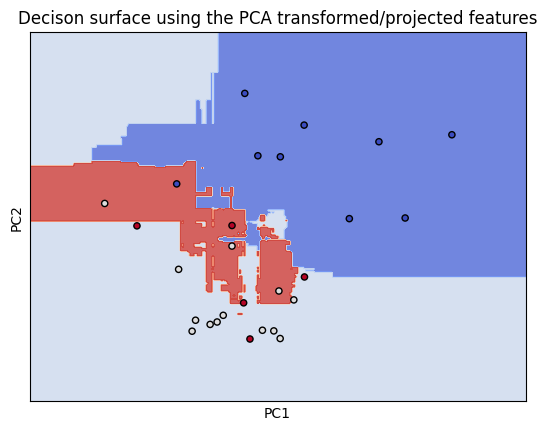

In [78]:
# Plotando
y = y_test
fig, ax = plt.subplots()

# Set-up grid for plotting.
X0, X1 = X_test_pca[:, 0], X_test_pca[:, 1] # ATENÇÃO: Validar se seu X_test com PCA tem o mesmo nome
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, voting, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('PC2')
ax.set_xlabel('PC1')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title('Decison surface using the PCA transformed/projected features')
plt.show()

In [98]:
voting2 = VotingClassifier(estimators=[('KNN', KNeighborsClassifier()),
 ('tree', DecisionTreeClassifier()),('SVM', SVC()
  )], voting='hard')
voting2.fit(X_train_pca, y_train)

VotingClassifier(estimators=[('KNN', KNeighborsClassifier()),
                             ('tree', DecisionTreeClassifier()),
                             ('SVM', SVC())])

In [99]:
y_pred_voting2 = voting2.predict(X_test_pca)
print(classification_report(y_test, y_pred_voting2))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.82      0.69      0.75        13
           2       0.38      0.60      0.46         5

    accuracy                           0.74        27
   macro avg       0.73      0.73      0.72        27
weighted avg       0.80      0.74      0.76        27



In [100]:
param_grid = {
    'KNN__n_neighbors': [3, 5, 7],
    'tree__max_depth': [3, 5, 7, 9],
    'SVM__C': [1, 10, 100],
    'SVM__gamma': [0.1, 1, 10],
    'SVM__kernel': ['linear', 'rbf']
}


In [102]:
grid_search = GridSearchCV(voting2, param_grid, cv=10, verbose=3)
grid_search.fit(X_train_pca, y_train)

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
[CV 1/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.812 total time=   0.0s
[CV 2/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.733 total time=   0.0s
[CV 3/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.533 total time=   0.0s
[CV 4/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.733 total time=   0.0s
[CV 5/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.933 total time=   0.0s
[CV 6/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.600 total time=   0.0s
[CV 7/10] END KNN__n_neighbors=3, SVM__C=1, SVM__gamma=0.1, SVM__kernel=linear, tree__max_depth=3;, score=0.800 total time=   0.0s
[CV 8/10] END KNN_

GridSearchCV(cv=10,
             estimator=VotingClassifier(estimators=[('KNN',
                                                     KNeighborsClassifier()),
                                                    ('tree',
                                                     DecisionTreeClassifier()),
                                                    ('SVM', SVC())]),
             param_grid={'KNN__n_neighbors': [3, 5, 7], 'SVM__C': [1, 10, 100],
                         'SVM__gamma': [0.1, 1, 10],
                         'SVM__kernel': ['linear', 'rbf'],
                         'tree__max_depth': [3, 5, 7, 9]},
             verbose=3)

In [86]:
y_pred_voting2 = grid_search.predict(X_test_pca)
print(classification_report(y_test, y_pred_voting2))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.82      0.69      0.75        13
           2       0.38      0.60      0.46         5

    accuracy                           0.74        27
   macro avg       0.73      0.73      0.72        27
weighted avg       0.80      0.74      0.76        27



In [88]:
grid_search.best_params_

{'KNN__n_neighbors': 3,
 'SVM__C': 100,
 'SVM__gamma': 0.1,
 'SVM__kernel': 'rbf',
 'tree__max_depth': 3}

In [89]:
grid_search.best_score_

0.8079166666666667

## Dataset Dígitos

In [ ]:
# Carregando o dataset de dígitos
d_digits = datasets.load_digits(as_frame=True)

In [ ]:
d_digits

In [ ]:
df = pd.DataFrame(d_digits.data)
df.head()

In [ ]:
# Visualização dos dados
im = df.iloc[39,:].values

In [ ]:
im_r = im.reshape(8,8)

In [ ]:
plt.imshow(im_r, cmap='gray')

In [ ]:
d_digits.images.shape

In [ ]:
plt.imshow(d_digits.images[12], cmap='gray')

In [ ]:
df['target'] = d_digits.target

In [ ]:
df

In [ ]:
# Predict sem PCA
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.2, random_state=42)

## Exercício com dataset data_cancer (comparação)

## Exercício de classificação de textos (Tweets)

In [111]:
# Lendo o Dataset
tweets_data = pd.read_csv('/content/train.csv')

In [112]:
tweets_data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [113]:
tweets_data.target.value_counts()

,count
target,
0,4342
1,3271


In [116]:
tweets_data.iloc[2345,3]

"General News \x89Û¢åÊ'Demolition of houses on waterways begins at Achimota Mile 7 ' via @233liveOnline. Full story at http://t.co/iO7kUUg1uq"

In [117]:
tweets_data.iloc[2345]

,2345
id,3373
keyword,demolition
location,NaN
text,General News Û¢åÊ'Demolition of houses on wat...
target,0


In [118]:
from sklearn.feature_extraction.text import CountVectorizer

In [119]:
bow_vec = CountVectorizer(stop_words='english')

In [120]:
bow_tweet = bow_vec.fit_transform(tweets_data['text'])

In [121]:
bow_tweet.shape

(7613, 21363)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(bow_tweet, tweets_data.target, test_size=0.2, random_state=42)

In [123]:
X_train.shape

(6090, 21363)

In [124]:
grad_boost = GradientBoostingClassifier()
grad_boost.fit(X_train, y_train)

GradientBoostingClassifier()

In [125]:
grad_boost.score(X_test, y_test)

0.7616546290216678

In [134]:
X_test_e = ['Earthquake !! Storm Approaching','Amazon big deal approaches']

In [128]:
grad_boost.predict(bow_vec.transform(X_test))

array([1, 0])

In [129]:
text_pipe = Pipeline([
    ('bow', CountVectorizer(stop_words='english')),
    ('boost', GradientBoostingClassifier())
])

In [131]:
X_train, X_test, y_train, y_test = train_test_split(tweets_data.text, tweets_data.target, test_size=0.2, random_state=42)

In [132]:
text_pipe.fit(X_train, y_train)

Pipeline(steps=[('bow', CountVectorizer(stop_words='english')),
                ('boost', GradientBoostingClassifier())])

In [135]:
text_pipe.predict(X_test_e)

array([1, 0])

In [136]:
text_pipe.score(X_test, y_test)

0.7603414313854235

In [137]:
param_grid = {
    'bow__ngram_range': [(1,1), (1,2), (2,2)],
    'boost__n_estimators': [10, 100]
}

In [138]:
text_grid = GridSearchCV(text_pipe, param_grid, cv=10, verbose=3)

In [139]:
text_grid.fit(X_train, y_train)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
[CV 1/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.675 total time=   1.1s
[CV 2/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.668 total time=   1.2s
[CV 3/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.658 total time=   1.1s
[CV 4/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.701 total time=   1.2s
[CV 5/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.698 total time=   0.7s
[CV 6/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.662 total time=   0.7s
[CV 7/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.622 total time=   0.7s
[CV 8/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.650 total time=   0.7s
[CV 9/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.672 total time=   0.7s
[CV 10/10] END boost__n_estimators=10, bow__ngram_range=(1, 1);, score=0.668 total t

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('bow',
                                        CountVectorizer(stop_words='english')),
                                       ('boost',
                                        GradientBoostingClassifier())]),
             param_grid={'boost__n_estimators': [10, 100],
                         'bow__ngram_range': [(1, 1), (1, 2), (2, 2)]},
             verbose=3)

In [140]:
voting2

VotingClassifier(estimators=[('KNN', KNeighborsClassifier()),
                             ('tree', DecisionTreeClassifier()),
                             ('SVM', SVC())])

In [143]:
text_grid.best_params_

{'boost__n_estimators': 100, 'bow__ngram_range': (1, 1)}

In [144]:
text_grid.best_score_

0.7520525451559934

In [141]:
text_pipe = Pipeline([
    ('bow', CountVectorizer(stop_words='english')),
    ('voting', voting2)
])

In [142]:
param_grid = {
    'bow__ngram_range': [(1,1), (1,2), (2,2)],
    'voting__KNN__n_neighbors': [3, 5, 7],
    'voting__tree__max_depth': [3, 5, 7, 9],
    'voting__SVM__C': [1, 10, 100],
    'voting__SVM__gamma': [0.1, 1, 10],
    'voting__SVM__kernel': ['linear', 'rbf']
}

In [145]:
text_voting = GridSearchCV(text_pipe, param_grid, verbose=3, scoring='f1')

In [146]:
text_voting.fit(X_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV 1/5] END bow__ngram_range=(1, 1), voting__KNN__n_neighbors=3, voting__SVM__C=1, voting__SVM__gamma=0.1, voting__SVM__kernel=linear, voting__tree__max_depth=3;, score=0.647 total time=   6.0s
[CV 2/5] END bow__ngram_range=(1, 1), voting__KNN__n_neighbors=3, voting__SVM__C=1, voting__SVM__gamma=0.1, voting__SVM__kernel=linear, voting__tree__max_depth=3;, score=0.711 total time=   5.3s
[CV 3/5] END bow__ngram_range=(1, 1), voting__KNN__n_neighbors=3, voting__SVM__C=1, voting__SVM__gamma=0.1, voting__SVM__kernel=linear, voting__tree__max_depth=3;, score=0.694 total time=   3.6s
[CV 4/5] END bow__ngram_range=(1, 1), voting__KNN__n_neighbors=3, voting__SVM__C=1, voting__SVM__gamma=0.1, voting__SVM__kernel=linear, voting__tree__max_depth=3;, score=0.651 total time=   4.4s
[CV 5/5] END bow__ngram_range=(1, 1), voting__KNN__n_neighbors=3, voting__SVM__C=1, voting__SVM__gamma=0.1, voting__SVM__kernel=linear, voting__tree__max_de

KeyboardInterrupt: 

In [ ]:
text_voting.best_params_

In [ ]:
text_voting.best_score_